# Heart attack risk prediction project

# Classification
### Today I want to practice on a CLASSIFICATION PROJECT
Based on the following comprehensive medical information about a patient, we need to predict whether a patient has a low chance or a high chance of a heart attack?!

Age: Patient's A
e

Sex: Gender

Exercise Induced Angina (exang): Does the chest pain start with a specific activity?

Number 1 means Yes

Number 0 means No

Number of Major Vessels (ca): A value from 0 to 3

Chest Pain Type (cp):

Value 1: Typical angina (direct heart-related pain)

Value 2: Atypical angina (indirect pain that leads to feeling pain in the heart)

Value 3: Non-anginal pain (non-cardiac pain)

Value 4: Asymptomatic (no symptoms)

Resting Blood Pressure (trtbps): Blood pressure at rest

Cholesterol (chol): Cholesterol level

Fasting Blood Sugar > 120 mg/dl – Diabetes (fbs):

Value 1: Has high fasting blood sugar (diabetes)

Value 0: Does not have high fasting blood sugar

Resting Electrocardiogram Results (rest_ecg):

Value 0: Normal

Value 1: Having ST-T wave abnormality

Value 2: Showing probable or definite left ventricular hypertrophy

Maximum Heart Rate Achieved (thalach): Maximum heart rate

Chance of Heart Attack (target):

Value 0: Low chance

Value 1: High chance

#### Import necessary libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

#### Loading and initial data exploration

In [24]:
df = pd.read_csv('16325569497737558.csv')

In [25]:
print("Check the dimensions of the data :")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")
print("\n" + "="*50)

print("General data information :")
print(df.info())
print("\n" + "="*50)

print("Check for duplicate values :")
print(f"Number of duplicate data: {df.duplicated().sum()}")
print("\n" + "="*50)

Check the dimensions of the data :
Number of samples: 303
Number of features: 14

General data information :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

Check for duplicate values :
Number of duplicate data: 1



#### Advanced exploratory analysis

##### Descriptive statistics and target distribution

Descriptive statistics of data :
              age         sex          cp      trtbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg    thalachh        exng     oldpeak         slp         caa  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean     0.528053  149.646865    0.326733    1.039604    1.399340    0.7293

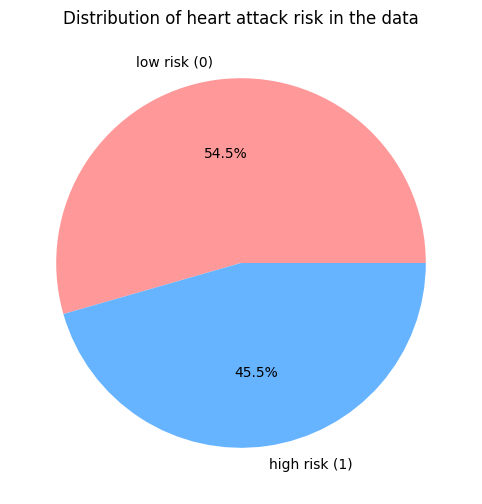

In [26]:
print("Descriptive statistics of data :")
print(df.describe())
print("\n" + "="*50)

print("Heart attack risk distribution (target):")
target_dist = df['output'].value_counts()
print(target_dist)
print(f"\nHigh to low risk ratio: {target_dist[1]/target_dist[0]:.2f}")

plt.figure(figsize=(8, 6))
plt.pie(target_dist.values, labels=['low risk (0)', 'high risk (1)'], autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'])
plt.title('Distribution of heart attack risk in the data')
plt.show()

##### Histograms and boxplots for all features

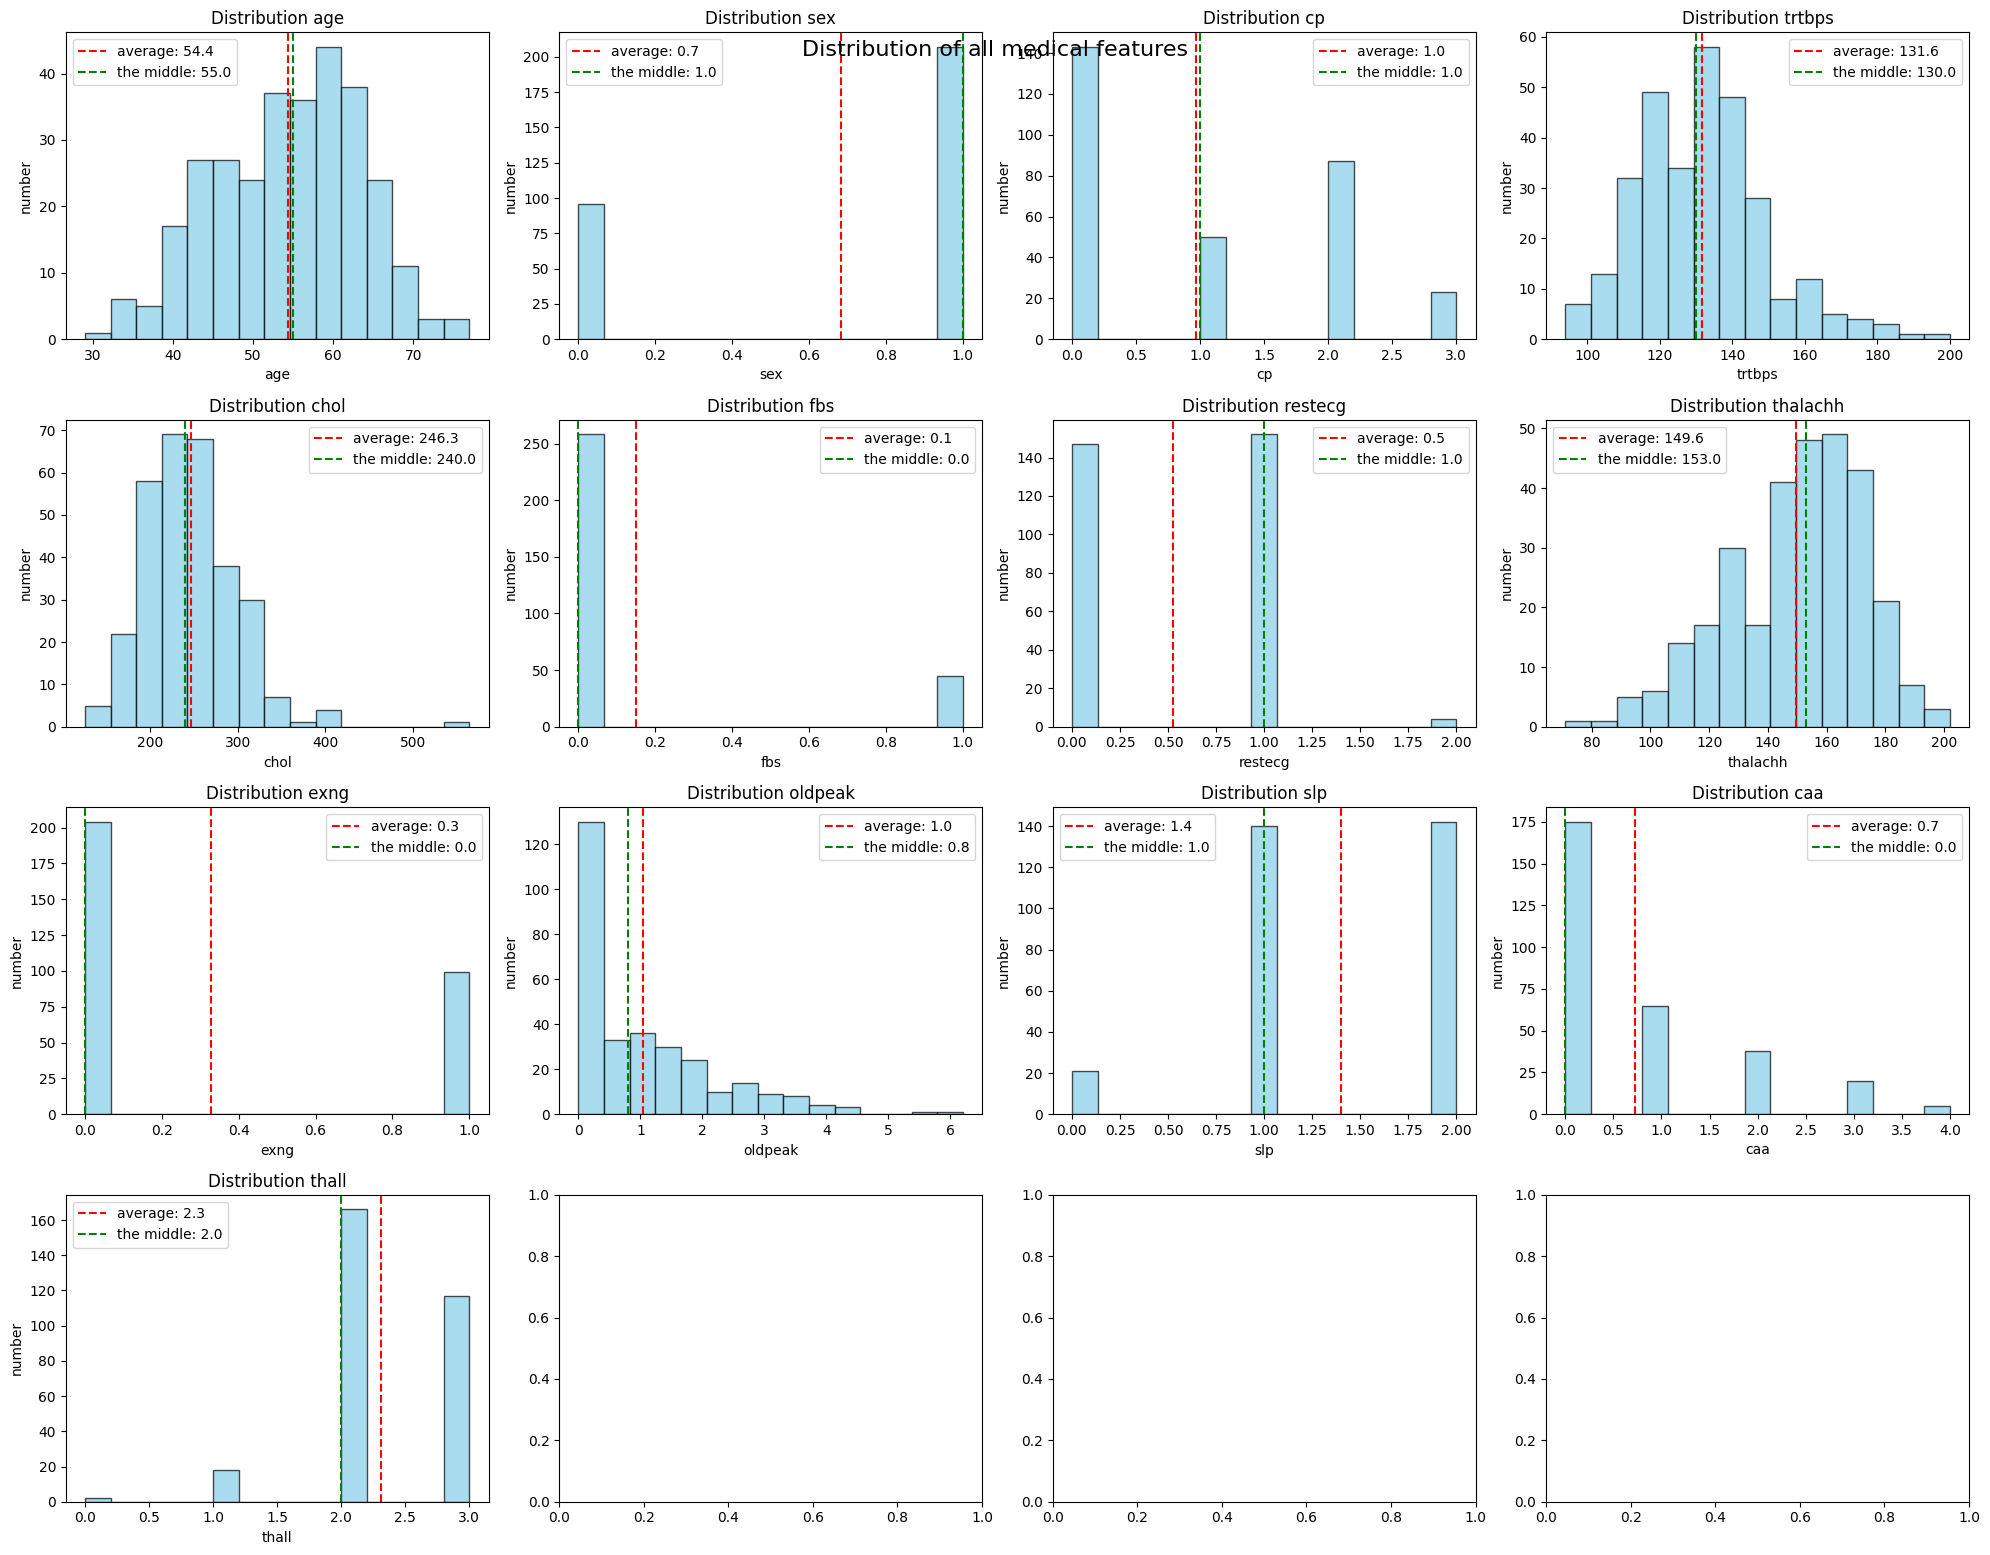

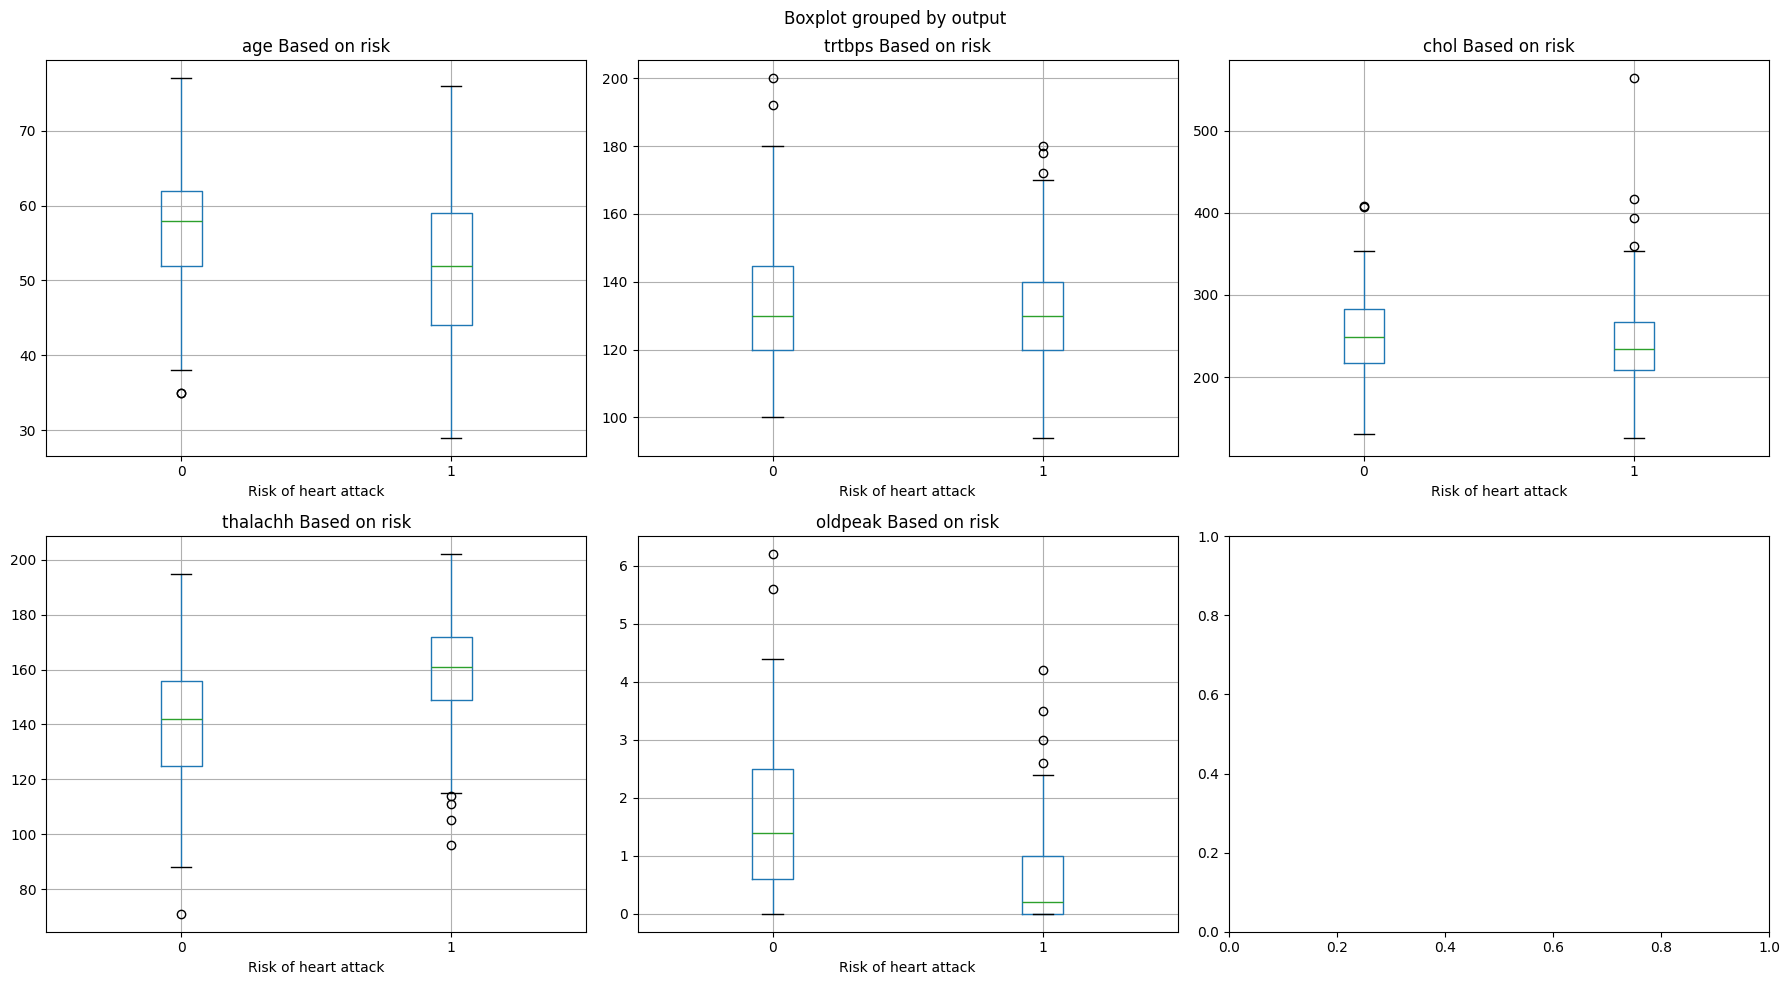

In [27]:
plt.rcParams['font.family'] = 'DejaVu Sans'
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
fig.suptitle('Distribution of all medical features', fontsize=16, y=0.95)

features = ['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 
           'thalachh', 'exng', 'oldpeak', 'slp', 'caa', 'thall']

for i, feature in enumerate(features):
    row, col = i // 4, i % 4
    
    axes[row, col].hist(df[feature], bins=15, alpha=0.7, color='skyblue', edgecolor='black')
    axes[row, col].set_title(f'Distribution {feature}')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('number')
    
    mean_val = df[feature].mean()
    median_val = df[feature].median()
    axes[row, col].axvline(mean_val, color='red', linestyle='--', label=f'average: {mean_val:.1f}')
    axes[row, col].axvline(median_val, color='green', linestyle='--', label=f'the middle: {median_val:.1f}')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

num_features = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparison of numerical characteristics based on heart attack risk', fontsize=16)

for i, feature in enumerate(num_features):
    row, col = i // 3, i % 3
    df.boxplot(column=feature, by='output', ax=axes[row, col])
    axes[row, col].set_title(f'{feature} Based on risk')
    axes[row, col].set_xlabel('Risk of heart attack')

plt.tight_layout()
plt.show()

##### correlation matrix

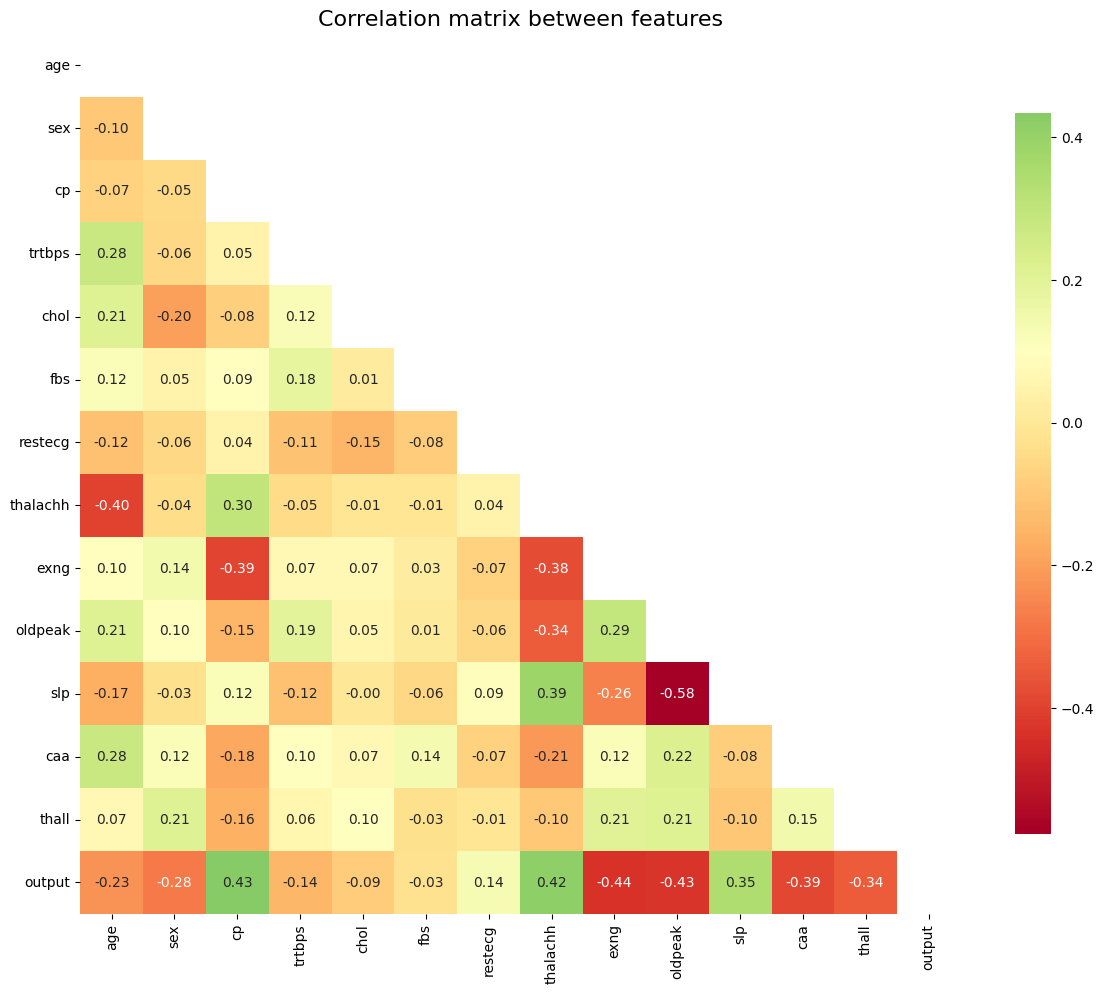

Correlation of characteristics with heart attack risk: 
output      1.000000
cp          0.433798
thalachh    0.421741
slp         0.345877
restecg     0.137230
fbs        -0.028046
chol       -0.085239
trtbps     -0.144931
age        -0.225439
sex        -0.280937
thall      -0.344029
caa        -0.391724
oldpeak    -0.430696
exng       -0.436757
Name: output, dtype: float64


In [28]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdYlGn', center=0.1,
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Correlation matrix between features', fontsize=16)
plt.tight_layout()
plt.show()

print("Correlation of characteristics with heart attack risk: ")
target_corr = df.corr()['output'].sort_values(ascending=False)
print(target_corr)

# Important scatter plots

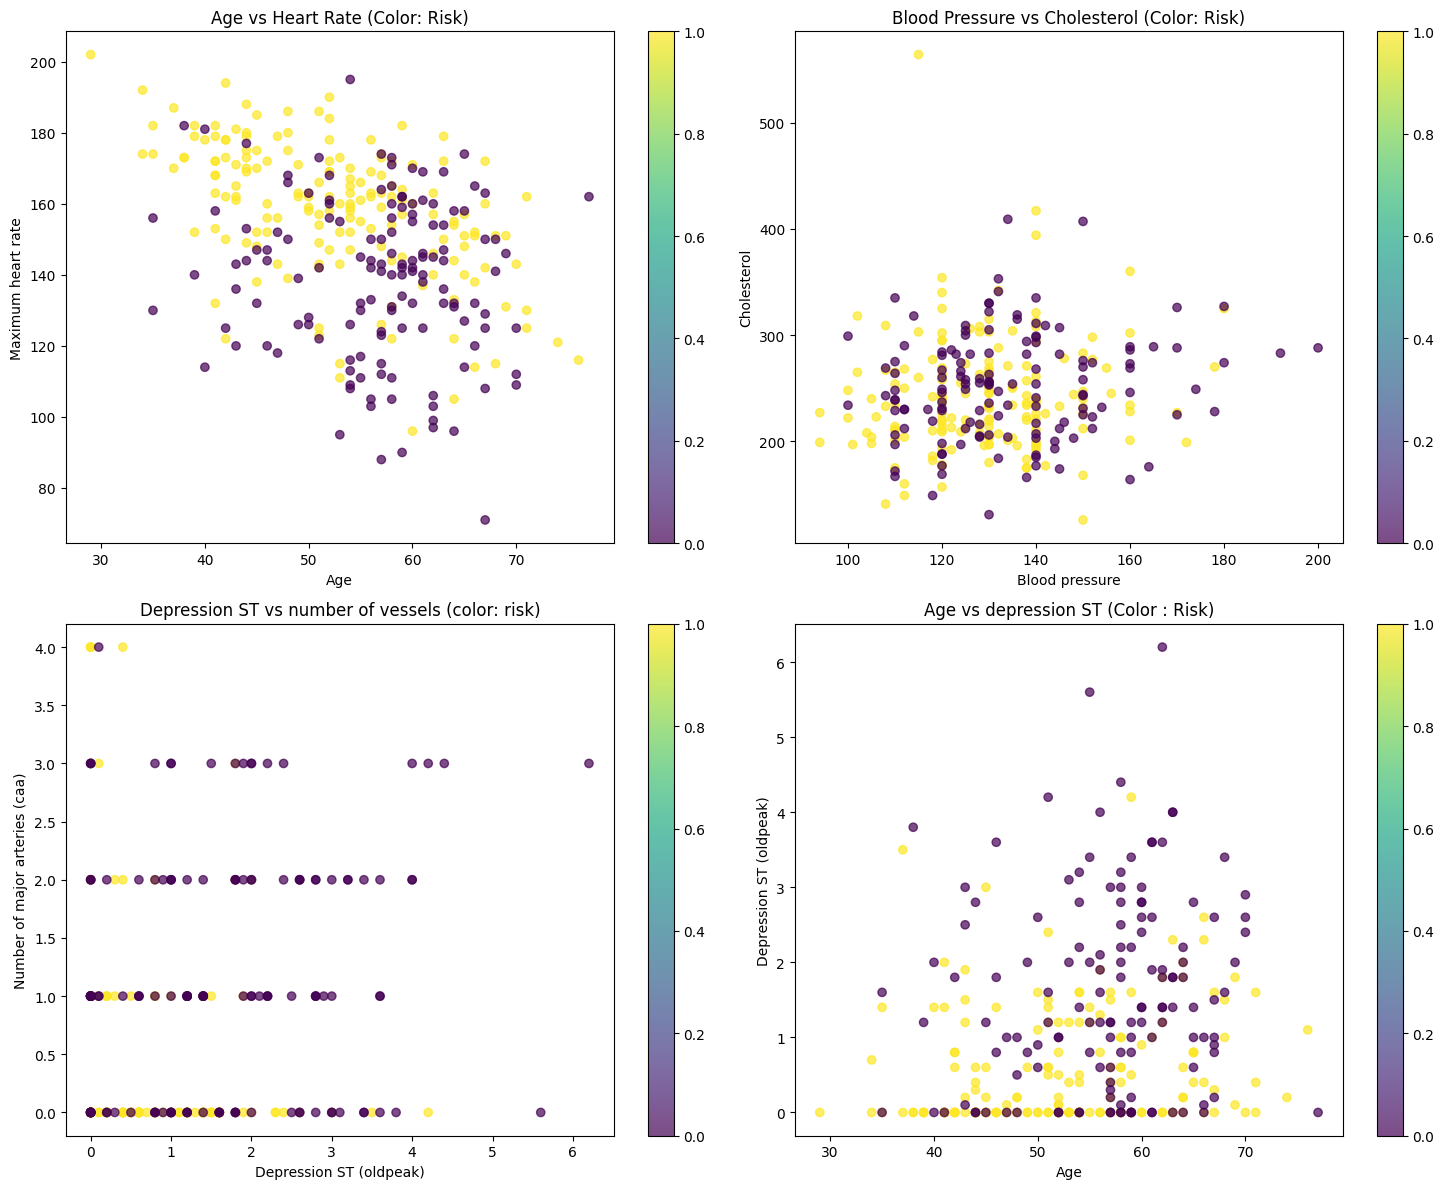

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

scatter1 = axes[0, 0].scatter(df['age'], df['thalachh'], c=df['output'], cmap='viridis', alpha=0.7)
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Maximum heart rate')
axes[0, 0].set_title('Age vs Heart Rate (Color: Risk)')
plt.colorbar(scatter1, ax=axes[0, 0])

scatter2 = axes[0, 1].scatter(df['trtbps'], df['chol'], c=df['output'], cmap='viridis', alpha=0.7)
axes[0, 1].set_xlabel('Blood pressure')
axes[0, 1].set_ylabel('Cholesterol')
axes[0, 1].set_title('Blood Pressure vs Cholesterol (Color: Risk)')
plt.colorbar(scatter2, ax=axes[0, 1])

scatter3 = axes[1, 0].scatter(df['oldpeak'], df['caa'], c=df['output'], cmap='viridis', alpha=0.7)
axes[1, 0].set_xlabel('Depression ST (oldpeak)')
axes[1, 0].set_ylabel('Number of major arteries (caa)')
axes[1, 0].set_title('Depression ST vs number of vessels (color: risk)')
plt.colorbar(scatter3, ax=axes[1, 0])

scatter4 = axes[1, 1].scatter(df['age'], df['oldpeak'], c=df['output'], cmap='viridis', alpha=0.7)
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Depression ST (oldpeak)')
axes[1, 1].set_title('Age vs depression ST (Color : Risk)')
plt.colorbar(scatter4, ax=axes[1, 1])

plt.tight_layout()
plt.show()

##### Data preprocessing

In [30]:
print("Check for irrational values :")
print(f"Minimum Blood Pressure: {df['trtbps'].min()}")
print(f"Minimum Cholesterol: {df['chol'].min()}")
print(f"Minimum Heart Rate: {df['thalachh'].min()}")

X = df.drop('output', axis=1)
y = df['output']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
num_cols = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"\n Dimensions of training data: {X_train.shape}")
print(f" Dimensions of test data: {X_test.shape}")

Check for irrational values :
Minimum Blood Pressure: 94
Minimum Cholesterol: 126
Minimum Heart Rate: 71

 Dimensions of training data: (242, 13)
 Dimensions of test data: (61, 13)


##### Building and training machine learning models

In [32]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

results = {}
predictions = {}

print(" Model training in progress...")
print("="*60)

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    predictions[name] = (y_pred, y_pred_proba)
    
    accuracy = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'accuracy': accuracy,
        'auc': auc_score
    }
    
    print(f"--> {name}:")
    print(f"   (Accuracy): {accuracy:.4f}")
    print(f"   (AUC): {auc_score:.4f}")
    print("-" * 40)
    

 Model training in progress...
--> Logistic Regression:
   (Accuracy): 0.8033
   (AUC): 0.8658
----------------------------------------
--> Random Forest:
   (Accuracy): 0.8361
   (AUC): 0.9102
----------------------------------------
--> SVM:
   (Accuracy): 0.8033
   (AUC): 0.8712
----------------------------------------


#### Comprehensive evaluation of models
##### Comparing the performance of models

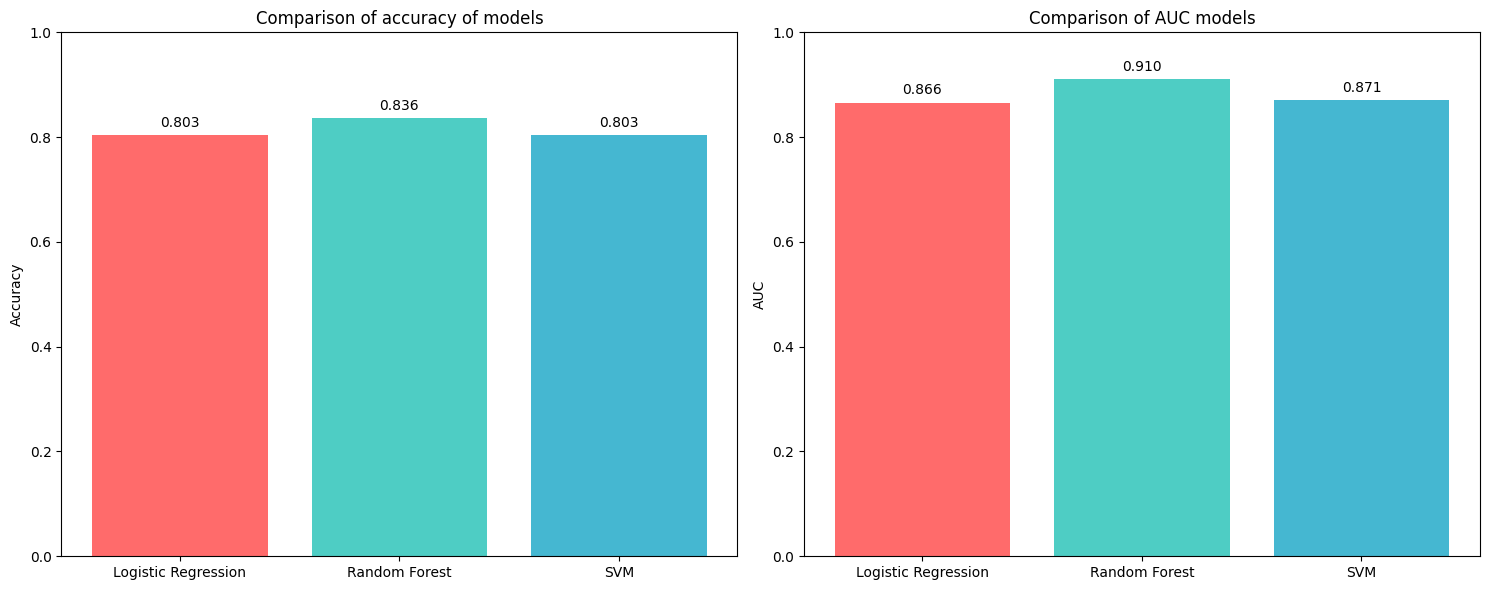

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

accuracies = [results[name]['accuracy'] for name in models.keys()]
ax1.bar(models.keys(), accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax1.set_title('Comparison of accuracy of models')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
for i, v in enumerate(accuracies):
    ax1.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

auc_scores = [results[name]['auc'] for name in models.keys()]
ax2.bar(models.keys(), auc_scores, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax2.set_title('Comparison of AUC models')
ax2.set_ylabel('AUC')
ax2.set_ylim(0, 1)
for i, v in enumerate(auc_scores):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

##### ROC curve

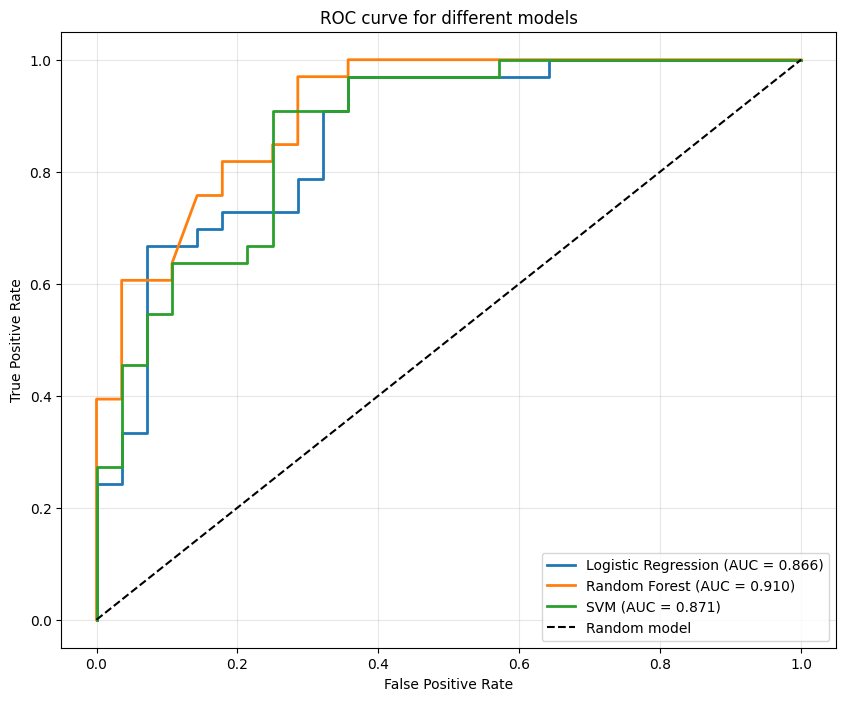

In [34]:
plt.figure(figsize=(10, 8))

for name, (y_pred, y_pred_proba) in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve for different models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##### Wrong matrix for the best model

 The best model: Random Forest


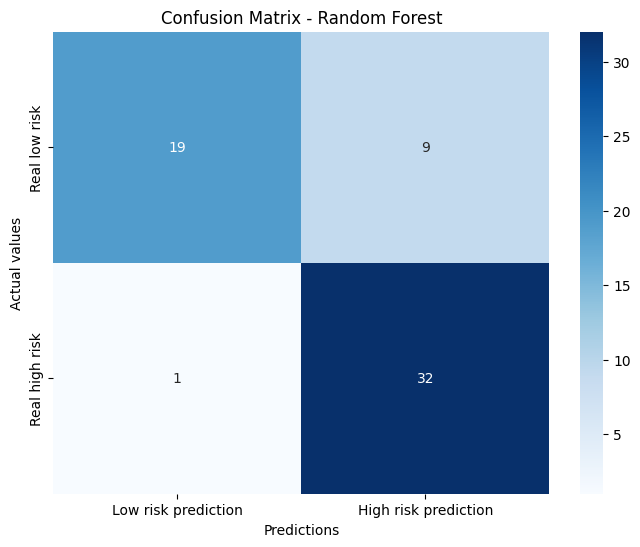

 Classification report for Random Forest:
              precision    recall  f1-score   support

    Low Risk       0.95      0.68      0.79        28
   High Risk       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61



In [35]:
best_model_name = max(results.items(), key=lambda x: x[1]['auc'])[0]
best_predictions = predictions[best_model_name][0]

print(f" The best model: {best_model_name}")
print("="*50)

cm = confusion_matrix(y_test, best_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low risk prediction', 'High risk prediction'],
            yticklabels=['Real low risk', 'Real high risk'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual values')
plt.xlabel('Predictions')
plt.show()

print(f" Classification report for {best_model_name}:")
print(classification_report(y_test, best_predictions, 
                          target_names=['Low Risk', 'High Risk']))

##### The importance of features in the best model

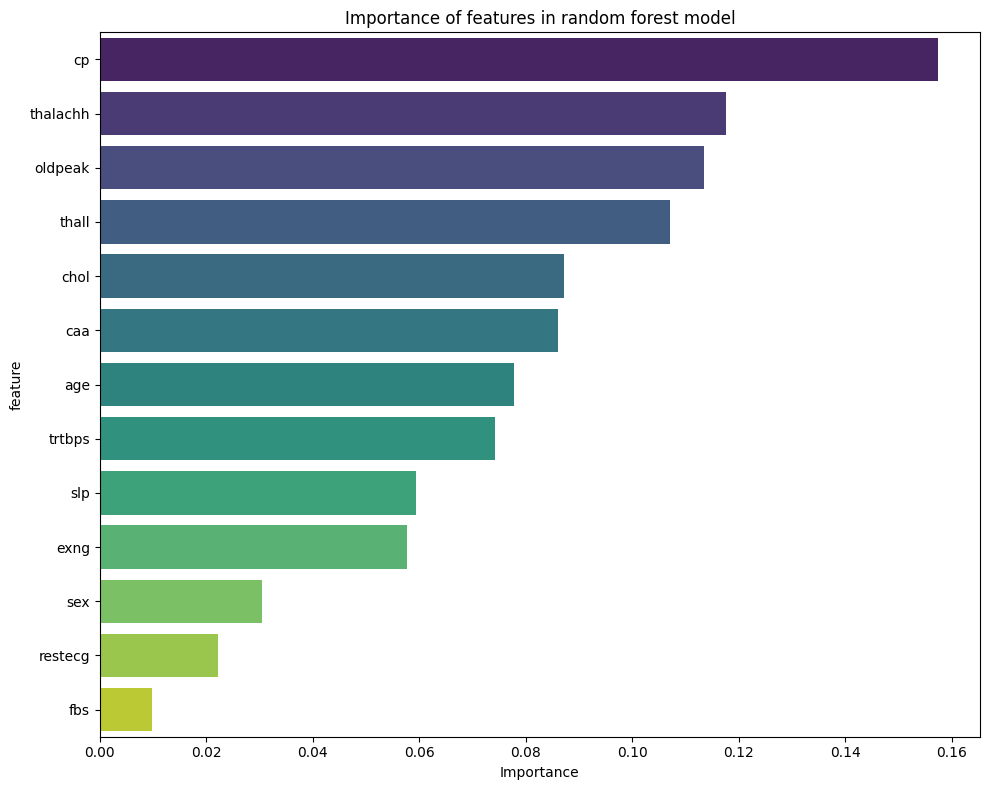

 The most important features for predicting heart attack risk: 
     feature  importance
2         cp    0.157392
7   thalachh    0.117491
9    oldpeak    0.113399
12     thall    0.107062
4       chol    0.087131
11       caa    0.086078
0        age    0.077759
3     trtbps    0.074127
10       slp    0.059454
8       exng    0.057655


In [36]:
if best_model_name == 'Random Forest':
    best_model = models['Random Forest']
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
    plt.title('Importance of features in random forest model')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    
    print(" The most important features for predicting heart attack risk: ")
    print(feature_importance.head(10))

#### Final conclusion and sample prediction

In [37]:
print(" Final Conclusion:")
print("="*50)

final_results = pd.DataFrame(results).T
final_results = final_results.sort_values('auc', ascending=False)
print(final_results)

print(f"\n Key insights:")
print("1️- The {best_model_name} model performs best in predicting heart attack risk")
print("2️- The most important risk factors based on data analysis:")
print("   - Number of main arteries involved (caa)")
print("   - Type of chest pain (cp)") 
print("   - Maximum heart rate (thalachh)")
print("   - ST segment depression (oldpeak)")
print("3️- The overall length of the models is between 80-85%, which is acceptable for medical use")

print(f"\n Sample forecast for a new patient:")
sample_patient = X_test.iloc[0:1]
best_model = models[best_model_name]
prediction = best_model.predict(sample_patient)[0]
probability = best_model.predict_proba(sample_patient)[0][1]

risk_level = "High" if prediction == 1 else "Low"
print(f"Risk of heart attack for this patient: {risk_level}")
print(f"The possibility of danger: {probability:.2%}")

 Final Conclusion:
                     accuracy       auc
Random Forest        0.836066  0.910173
SVM                  0.803279  0.871212
Logistic Regression  0.803279  0.865801

 Key insights:
1️- The {best_model_name} model performs best in predicting heart attack risk
2️- The most important risk factors based on data analysis:
   - Number of main arteries involved (caa)
   - Type of chest pain (cp)
   - Maximum heart rate (thalachh)
   - ST segment depression (oldpeak)
3️- The overall length of the models is between 80-85%, which is acceptable for medical use

 Sample forecast for a new patient:
Risk of heart attack for this patient: Low
The possibility of danger: 19.00%


### Thank you for completing this lab!
#### Author
##### Farzin Ahmadzade